## Exploración de datos y definición del plan de acción para el análisis

In [3]:
# Cargar librerias
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.stats.proportion import proportions_ztest, proportion_confint

In [4]:
# Cargar datos
df_regapp = pd.read_csv("datasets/logs_exp_us.csv", sep="\t")

In [5]:
# Mostrar estructura del dataset
df_regapp.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 244126 entries, 0 to 244125
Data columns (total 4 columns):
 #   Column          Non-Null Count   Dtype 
---  ------          --------------   ----- 
 0   EventName       244126 non-null  object
 1   DeviceIDHash    244126 non-null  int64 
 2   EventTimestamp  244126 non-null  int64 
 3   ExpId           244126 non-null  int64 
dtypes: int64(3), object(1)
memory usage: 7.5+ MB


In [6]:
# Generar muestra del dataset
df_regapp.sample(10)

,EventName,DeviceIDHash,EventTimestamp,ExpId
217173,PaymentScreenSuccessful,750314308970627725,1565159025,248
201889,OffersScreenAppear,1975349697076725883,1565106673,248
49569,CartScreenAppear,4248542169188105293,1564737565,248
99259,MainScreenAppear,8756616505879437995,1564848430,248
51788,MainScreenAppear,790376913952472135,1564741056,247
112520,OffersScreenAppear,6677547829735824843,1564902768,246
43164,MainScreenAppear,8512398249440151661,1564723137,246
126586,OffersScreenAppear,663948373672770349,1564926487,247
131572,MainScreenAppear,4314327824451217942,1564934541,247
215745,MainScreenAppear,7060940278888962128,1565154819,247


In [7]:
# Mostrar eventos registrados
df_regapp["EventName"].unique()

array(['MainScreenAppear', 'PaymentScreenSuccessful', 'CartScreenAppear',
       'OffersScreenAppear', 'Tutorial'], dtype=object)

In [8]:
# Mostrar grupos registrados
df_regapp["ExpId"].unique()

array([246, 248, 247])

In [9]:
# Verificar si grupos están balanceados
df_regapp["ExpId"].value_counts(normalize = True)

ExpId
248    0.351241
246    0.328945
247    0.319814
Name: proportion, dtype: float64

In [10]:
# Mostrar cantidad de usuarios en experimento
df_regapp["DeviceIDHash"].nunique()

7551

**PLAN DE ACCIÓN PARA PREPARACIÓN DE DATOS**

- Se deben ajustar los nombres de las columnas a formato snake_case. Además convendría cambiar los nombres del dataset por unos más didácticos y comprensibles.
- La columna que registra el marcador temporal debe cambiarse a un formato de fecha para a partir de aquí extraer el componente de día en que se dio el experimento.
- Existe el evento “Tutorial” que corresponde seguramente a usuarios que ingresaron a la pantalla de ayuda. Este evento no es parte del embudo por lo que debería eliminarse.
- Se podría modificar los valores de la columna del grupo experimental a fin de hacerlos más comprensibles (A, B1 y B2).

## Preparación de datos para el análisis

Ejecutamos plan de acción definido.

In [11]:
# Ajustar los nombres de las columnas
df_regapp = df_regapp.rename(columns = {
    "EventName": "event",
    "DeviceIDHash": "user",
    "EventTimestamp": "timestamp",
    "ExpId": "group",
})
df_regapp.columns

Index(['event', 'user', 'timestamp', 'group'], dtype='object')

In [12]:
# Cambiar el tipo de la columna timestamp
df_regapp["timestamp"] = pd.to_datetime(df_regapp["timestamp"], unit = "s")
df_regapp.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 244126 entries, 0 to 244125
Data columns (total 4 columns):
 #   Column     Non-Null Count   Dtype         
---  ------     --------------   -----         
 0   event      244126 non-null  object        
 1   user       244126 non-null  int64         
 2   timestamp  244126 non-null  datetime64[ns]
 3   group      244126 non-null  int64         
dtypes: datetime64[ns](1), int64(2), object(1)
memory usage: 7.5+ MB


In [13]:
df_regapp.sample(5)

,event,user,timestamp,group
237157,MainScreenAppear,735988361736939206,2019-08-07 16:40:43,247
205678,MainScreenAppear,6213626876710715478,2019-08-06 17:21:21,246
178262,OffersScreenAppear,8185637194647772317,2019-08-06 03:31:35,246
46487,OffersScreenAppear,3792176436818583594,2019-08-02 07:45:55,246
87519,OffersScreenAppear,2187914245613435519,2019-08-03 11:13:36,248


In [14]:
# Extraer componente de dia del experimento
df_regapp["day"] = df_regapp["timestamp"].dt.date
df_regapp.sample(5)

,event,user,timestamp,group,day
74547,MainScreenAppear,588147008884009969,2019-08-02 23:24:56,247,2019-08-02
65133,OffersScreenAppear,8551304834996164071,2019-08-02 16:14:11,247,2019-08-02
73503,MainScreenAppear,4123270163943493691,2019-08-02 21:01:10,247,2019-08-02
215564,MainScreenAppear,1632051821177645319,2019-08-07 05:02:38,246,2019-08-07
133708,CartScreenAppear,5996739817823449506,2019-08-04 17:00:51,248,2019-08-04


In [15]:
# Eliminar evento "Tutorial"
df_regapp = df_regapp.query("event != 'Tutorial'")

In [16]:
# Cambiar valores de grupo
dict_grupo = {
    246: "A1",
    247: "A2",
    248: "B"
}

df_regapp["group"] = df_regapp["group"].map(dict_grupo)
df_regapp["group"].unique()

array(['A1', 'B', 'A2'], dtype=object)

## Estudio y comprobación de datos
Vamos a ejecutar un análisis exploratorio de los datos para tener un conocimiento general respecto a algunos indicadores asociados al experimento.

In [17]:
# Eventos restantes al quitar el evento "Tutorial"
df_regapp["event"].unique()

array(['MainScreenAppear', 'PaymentScreenSuccessful', 'CartScreenAppear',
       'OffersScreenAppear'], dtype=object)

In [18]:
# Número de usuarios en los registros
df_regapp["user"].nunique()

7547

In [19]:
# Promedio de eventos por usuario
mean_events_users = df_regapp.groupby("user")["event"].count().mean()
print(f"Promedio de eventos por usuario: {mean_events_users:.2f}")

Promedio de eventos por usuario: 32.21


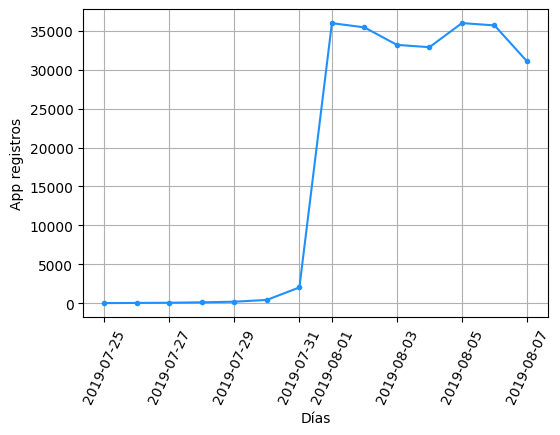

In [20]:
# Mostrar registros en la aplicación por dia
(
    df_regapp["day"]
    .value_counts()
    .sort_index()
    .plot(
        marker = ".",
        figsize = [6,4],
        grid = True,
        color = "dodgerblue",
        xlabel = "Días",
        ylabel = "App registros",
        rot = 65
    )
)
plt.show()

Los registros para la primera semana del experimento son prácticamente inexistentes, lo cual puede estar asociado a un problema en el proceso de recoleccion de información. A fin de garantizar mejores resultados en las pruebas A/B a realizar, se deben eliminar estos datos.

In [21]:
df_regapp = df_regapp.query("timestamp >= '2019-08-01'")
df_regapp.info()

<class 'pandas.core.frame.DataFrame'>
Index: 240259 entries, 2829 to 244125
Data columns (total 5 columns):
 #   Column     Non-Null Count   Dtype         
---  ------     --------------   -----         
 0   event      240259 non-null  object        
 1   user       240259 non-null  int64         
 2   timestamp  240259 non-null  datetime64[ns]
 3   group      240259 non-null  object        
 4   day        240259 non-null  object        
dtypes: datetime64[ns](1), int64(1), object(3)
memory usage: 11.0+ MB


Solo se perdió al rededor de cuatro mil registros. No fueron muchos en comparación del tamaño del dataset.

In [22]:
# Mostrar usuarios por grupo
(
    df_regapp
    .groupby("group")
    .agg(
        users = ("user","nunique")
    )
    .sort_index()
)

,users
group,
A1,2483
A2,2512
B,2535


## Estudio del embudo de eventos

In [23]:
# Registros en la aplicación por evento
df_regapp["event"].value_counts().sort_values(ascending = False)

event
MainScreenAppear           117431
OffersScreenAppear          46350
CartScreenAppear            42365
PaymentScreenSuccessful     34113
Name: count, dtype: int64

In [24]:
# Usuarios por evento
conv_general = (
    df_regapp
    .groupby("event")
    .agg(
        users = ("user","nunique")
    )
    .sort_values(by = "users", ascending = False)
)
conv_general

,users
event,
MainScreenAppear,7419
OffersScreenAppear,4593
CartScreenAppear,3734
PaymentScreenSuccessful,3539


El orden de las acciones es tal como se muestra en la tabla:
1. MainScreenAppear          → Usuario entra a la app
2. OffersScreenAppear        → Usuario explora ofertas  
3. CartScreenAppear          → Usuario agrega productos al carrito
4. PaymentScreenSuccessful   → Usuario completa la compra

In [25]:
# Tasa de conversion entre eventos
conv_general["conv_rate"] = 100 * conv_general["users"] / conv_general["users"].max()
conv_general.round(1)

,users,conv_rate
event,,
MainScreenAppear,7419,100.0
OffersScreenAppear,4593,61.9
CartScreenAppear,3734,50.3
PaymentScreenSuccessful,3539,47.7


En la segunda etapa `(OffersScreenAppear)` es donde se pierde más usaurios. En la pantalla de ofertas de los productos se perdió al rededor del 38.1% de usuarios (abandono).

El 47.7% completa todo el viaje desde el primer evento `MainScreenAppear` hasta el último evento `PaymentScreenSuccessful`.

## Estudio de los resultados del experimento

In [26]:
# Número de usaurios en cada grupo
df_regapp.groupby("group")["user"].nunique()

group
A1    2483
A2    2512
B     2535
Name: user, dtype: int64

In [27]:
# Verificamos si la muestra está balanceada
df_regapp['group'].value_counts(normalize = True).round(2)

group
B     0.35
A1    0.33
A2    0.32
Name: proportion, dtype: float64

Tamaños son similares de los grupos.

In [28]:
# Estimar tasas de conversión por grupos
conv_grupos = df_regapp.pivot_table(
    index = "event",
    columns = "group",
    values = "user",
    aggfunc = "nunique"
).sort_values(by = "B", ascending = False)

conv_grupos = 100 * conv_grupos / conv_grupos.max()
conv_grupos.round(2)

group,A1,A2,B
event,,,
MainScreenAppear,100.00,100.00,100.00
OffersScreenAppear,62.94,61.39,61.41
CartScreenAppear,51.67,50.00,49.34
PaymentScreenSuccessful,48.98,46.77,47.37


**HIPOTESIS A EVALUAR**
- Hipótesis Nula: La tasa de convesión en OffersScreanAppear del grupo A1 es IGUAL a la del grupo A2.
- Hipótesis Alternativa: La tasa de conversión en OffersScreenAppear del grupo A1 es DISTINTA a la del grupo B2.

In [29]:
# Definimos función para test de hipótesis
def prueba_ab(g1, g2, etapa, alpha = 0.1, alt = 'two-sided'):
    
    print(f"PRUEBA EN ETAPA: {etapa}")

    # Extraer muestras de ambos grupos
    muestra_1 = df_regapp.query("group == @g1")
    muestra_2 = df_regapp.query("group == @g2")

    # Obtener cantidad de usuarios totales
    nobs = [
        muestra_1['user'].nunique(),
        muestra_2['user'].nunique()
    ]

    # Obtener cantidad de casos convertidos
    suc = [
        muestra_1.query("event == @etapa")["user"].nunique(),
        muestra_2.query("event == @etapa")["user"].nunique()
    ]

    # Ejecutar prueba estadística
    z, p = proportions_ztest(
    count = suc,
    nobs = nobs,
    alternative = alt
    )

    if p < alpha:
        print("RECHAZO H0")
    else:
        print("NO RECHAZO H0")

    print(f"Valor p: {p:.1%}")

    # Calcular intervalos de confianza para ambos grupos
    (inf_1, inf_2), (sup_1, sup_2) = proportion_confint(
    count = suc,
    nobs = nobs,
    alpha = alpha
    )

    print(f"Intervalo de confianza para {g1}: [{inf_1:.1%}, {sup_1:.1%}]")
    print(f"Intervalo de confianza para {g2}: [{inf_2:.1%}, {sup_2:.1%}]")

In [30]:

# Validar prueba para etapa OffersScreenAppear
prueba_ab('A1', 'A2', 'OffersScreenAppear')


PRUEBA EN ETAPA: OffersScreenAppear
NO RECHAZO H0
Valor p: 24.8%
Intervalo de confianza para A1: [60.5%, 63.7%]
Intervalo de confianza para A2: [58.9%, 62.1%]


In [31]:
# Validar prueba para etapa CartScreenAppear
prueba_ab('A1', 'A2', 'CartScreenAppear')

PRUEBA EN ETAPA: CartScreenAppear
NO RECHAZO H0
Valor p: 22.9%
Intervalo de confianza para A1: [49.3%, 52.6%]
Intervalo de confianza para A2: [47.6%, 50.9%]


In [32]:
# Validar prueba para etapa PaymentScreenSuccessful
prueba_ab('A1', 'A2', 'PaymentScreenSuccessful')

PRUEBA EN ETAPA: PaymentScreenSuccessful
NO RECHAZO H0
Valor p: 11.4%
Intervalo de confianza para A1: [46.7%, 50.0%]
Intervalo de confianza para A2: [44.5%, 47.7%]


**Conclusiones:**

- No hay diferencia estadísticamente significativa.
- El sistema de medición funciona correctamente.
- Los grupos están bien balanceados.
- Los grupos A1 y A2 se comportan igual.
- Se puede confiar en los resultados del test A/B.
- Se puede aprovechar que acabamos de comprobar que ambos grupos de `control` tienen niveles estadísticamente iguales por lo que bastaría se contraste los grupos `A1 y B`

**HIPÓTESIS A EVALUAR**

- Hipótesis nula: La tasa de conversión en `OffersScreenAppear` del grupo de control A1 es IGUAL al grupo de tratamiento B.
- Hipótesis alternativa: La tasa de conversión en `OffersScreenAppear` del grupo de control A1 es MAYOR al grupo de tratamiento B.

In [33]:
# Ejecutar prueba para etapa OffersScreenAppear
prueba_ab('A1', 'B', 'OffersScreenAppear', alt='larger')

PRUEBA EN ETAPA: OffersScreenAppear
NO RECHAZO H0
Valor p: 10.7%
Intervalo de confianza para A1: [60.5%, 63.7%]
Intervalo de confianza para B: [58.8%, 62.0%]


In [34]:
# Ejecutar prueba para etapa CartScreenAppear
prueba_ab('A1', 'B', 'CartScreenAppear', alt='larger')

PRUEBA EN ETAPA: CartScreenAppear
RECHAZO H0
Valor p: 4.0%
Intervalo de confianza para A1: [49.3%, 52.6%]
Intervalo de confianza para B: [46.9%, 50.2%]


In [35]:
# Ejecutar prueba para etapa PaymentScreenSuccessful
prueba_ab('A1', 'B', 'PaymentScreenSuccessful', alt='larger')

PRUEBA EN ETAPA: PaymentScreenSuccessful
NO RECHAZO H0
Valor p: 10.8%
Intervalo de confianza para A1: [46.7%, 50.0%]
Intervalo de confianza para B: [45.0%, 48.2%]


A un nivel de significancia del 10% se evidencian efectos negativos ante los cambios de fuentes en la aplicación de la empresa. Lo anterior tiene especial énfasis en la etapa `CartScreenAppear` del embudo que corresponde a la pantalla del carrito de compras.

En todo caso vale hacer referencia a las limitaciones encontradas durante el análisis:
- Se tuvieron que excluir datos de una semana entera del experimento lo cual podría restar confiabilidad y robustez a los resultados.
- Los efectos encontrados se los obtiene a significancias del 10%, producto de las limitaciones referidas en los datos. Si se diera una mayor rigurosidad a los test, las conclusiones alcanzadas podrían cambiar.

**Cantidad de pruebas relizadas:**
Conteo de tus pruebas de hipótesis:
Test A/A (validación del sistema):
1. A1 vs A2 en OffersScreenAppear
2. A1 vs A2 en CartScreenAppear 
3. A1 vs A2 en PaymentScreenSuccessful

Test A/B (experimento principal):
1. A1 vs B en OffersScreenAppear
2. A1 vs B en CartScreenAppear
3. A1 vs B en PaymentScreenSuccessful

Total: 6 pruebas de hipótesis

In [36]:
# Probabilidad de al menos un falso positivo:
prob_falso_positivo = 1 - (1 - 0.1)**6
print(f"Probabilidad de falso positivo: {prob_falso_positivo:.1%}")

Probabilidad de falso positivo: 46.9%


Con alpha igual a 10% y 6 pruebas, existe casi un 50% de probabilidad de encontrar una diferencia falsa.
Por lo cual aplicaremos aplicaremos `Correción de Holm-Bonferroni` para ajustar el nivel de significancia (alpha).

In [37]:
# Tus valores p (aprox.)
p_values = [0.248, 0.229, 0.114, 0.107, 0.04, 0.108]
alpha_original = 0.1

def holm_bonferroni(p_values, alpha=0.05):
    p = np.array(p_values)
    n = len(p)
    sorted_idx = np.argsort(p)
    sorted_p = p[sorted_idx]

    adjusted_alphas_sorted = [alpha / (n - i) for i in range(n)]

    rejections_sorted = [False] * n
    for i, (pval, adj) in enumerate(zip(sorted_p, adjusted_alphas_sorted)):
        if pval <= adj:
            rejections_sorted[i] = True
        else:
            break

    rejections = [False] * n
    adjusted_alphas = [0.0] * n
    for sorted_pos, orig_idx in enumerate(sorted_idx):
        rejections[orig_idx] = rejections_sorted[sorted_pos]
        adjusted_alphas[orig_idx] = adjusted_alphas_sorted[sorted_pos]

    return rejections, adjusted_alphas

rejections, thresholds = holm_bonferroni(p_values, alpha_original)

print("Resultados Holm-Bonferroni:")
test_names = ['A1 vs A2: Offers', 'A1 vs A2: Cart', 'A1 vs A2: Payment',
              'A1 vs B: Offers', 'A1 vs B: Cart', 'A1 vs B: Payment']
for name, p, thresh, reject in zip(test_names, p_values, thresholds, rejections):
    print(f"{name}: p={p:.3f}, umbral={thresh:.3f}, Rechazar H0: {reject}")

Resultados Holm-Bonferroni:
A1 vs A2: Offers: p=0.248, umbral=0.100, Rechazar H0: False
A1 vs A2: Cart: p=0.229, umbral=0.050, Rechazar H0: False
A1 vs A2: Payment: p=0.114, umbral=0.033, Rechazar H0: False
A1 vs B: Offers: p=0.107, umbral=0.020, Rechazar H0: False
A1 vs B: Cart: p=0.040, umbral=0.017, Rechazar H0: False
A1 vs B: Payment: p=0.108, umbral=0.025, Rechazar H0: False


In [38]:
test_names = ['A1 vs A2: Offers', 'A1 vs A2: Cart', 'A1 vs A2: Payment',
              'A1 vs B: Offers', 'A1 vs B: Cart', 'A1 vs B: Payment']

# p_values, thresholds, rejections ya calculados por holm_bonferroni
df_res = pd.DataFrame({
    'test': test_names,
    'p_value': p_values,
    'threshold': thresholds,
    'reject': rejections
})

print(df_res)
print('\nTests rechazados:', df_res[df_res['reject']]['test'].tolist())
print(f"Rechazadas: {df_res['reject'].sum()} de {len(df_res)}")

                test  p_value  threshold  reject
0   A1 vs A2: Offers    0.248   0.100000   False
1     A1 vs A2: Cart    0.229   0.050000   False
2  A1 vs A2: Payment    0.114   0.033333   False
3    A1 vs B: Offers    0.107   0.020000   False
4      A1 vs B: Cart    0.040   0.016667   False
5   A1 vs B: Payment    0.108   0.025000   False

Tests rechazados: []
Rechazadas: 0 de 6


**CONCLUSION:**

No hay evidencia suficientemente fuerte para declarar efectos significativos una vez controlado el error por múltiples comparaciones.